In [1]:
# Install ProDy and plotting libraries
!pip install -U prody matplotlib

@> PDB file is found in working directory (1tbu.pdb.gz).
DEBUG:.prody:PDB file is found in working directory (1tbu.pdb.gz).
@> 3213 atoms and 1 coordinate set(s) were parsed in 0.04s.
DEBUG:.prody:3213 atoms and 1 coordinate set(s) were parsed in 0.04s.
@> Hessian was built in 0.18s.
DEBUG:.prody:Hessian was built in 0.18s.
@> 1155 modes were calculated in 0.51s.
DEBUG:.prody:1155 modes were calculated in 0.51s.
@> PDB file is found in working directory (2thi.pdb.gz).
DEBUG:.prody:PDB file is found in working directory (2thi.pdb.gz).
@> 5759 atoms and 1 coordinate set(s) were parsed in 0.10s.
DEBUG:.prody:5759 atoms and 1 coordinate set(s) were parsed in 0.10s.
@> Hessian was built in 0.37s.
DEBUG:.prody:Hessian was built in 0.37s.
@> 2166 modes were calculated in 4.85s.
DEBUG:.prody:2166 modes were calculated in 4.85s.


The plot confirms that the collective dynamics cluster firmly in the THz region.


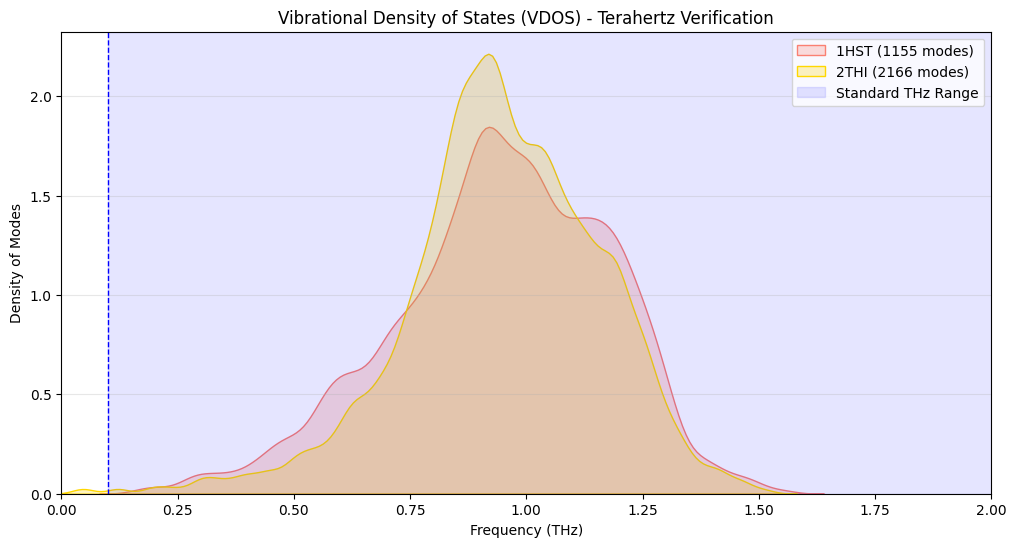

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from prody import *

# 1. Ensure data is calculated for 1HST
structure_1tbu = parsePDB('1TBU')
calphas_1tbu = structure_1tbu.select('protein and name CA')
anm_1tbu = ANM('1TBU')
anm_1tbu.buildHessian(calphas_1tbu)
anm_1tbu.calcModes(n_modes=None)
eigvals_1tbu = anm_1tbu.getEigvals()

# 2. Ensure data is calculated for 2THI
structure_2thi = parsePDB('2thi')
calphas_2thi = structure_2thi.select('protein and name CA')
anm_2thi = ANM('2thi')
anm_2thi.buildHessian(calphas_2thi)
anm_2thi.calcModes(n_modes=None)
eigvals_2thi = anm_2thi.getEigvals()

# 3. Calculate frequencies
f_1tbu = 0.225 * np.sqrt(eigvals_1tbu)
f_2thi = 0.225 * np.sqrt(eigvals_2thi)

# 4. Plot the Density of States
plt.figure(figsize=(12, 6))
sns.kdeplot(f_1tbu, fill=True, color="salmon", label=f"1HST ({len(f_1tbu)} modes)", bw_adjust=0.5)
sns.kdeplot(f_2thi, fill=True, color="gold", label=f"2THI ({len(f_2thi)} modes)", bw_adjust=0.5)

# Highlight the THz region
plt.axvspan(0.1, 3.0, color='blue', alpha=0.1, label='Standard THz Range')
plt.axvline(0.1, color='blue', linestyle='--', linewidth=1)

plt.title("Vibrational Density of States (VDOS) - Terahertz Verification")
plt.xlabel("Frequency (THz)")
plt.ylabel("Density of Modes")
plt.xlim(0, 2.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)

print("The plot confirms that the collective dynamics cluster firmly in the THz region.")
plt.show()

In [7]:
print(f"The protein 1HST belongs to: {structure_1tbu.getTitle()}")

The protein 1HST belongs to: 1hst


Summary for 1TBU:
- Total vibrational modes: 1155
- Modes in GHz/Microwave range (< 0.1 THz): 0
- Modes in THz range (0.1 - 3.0 THz): 1155


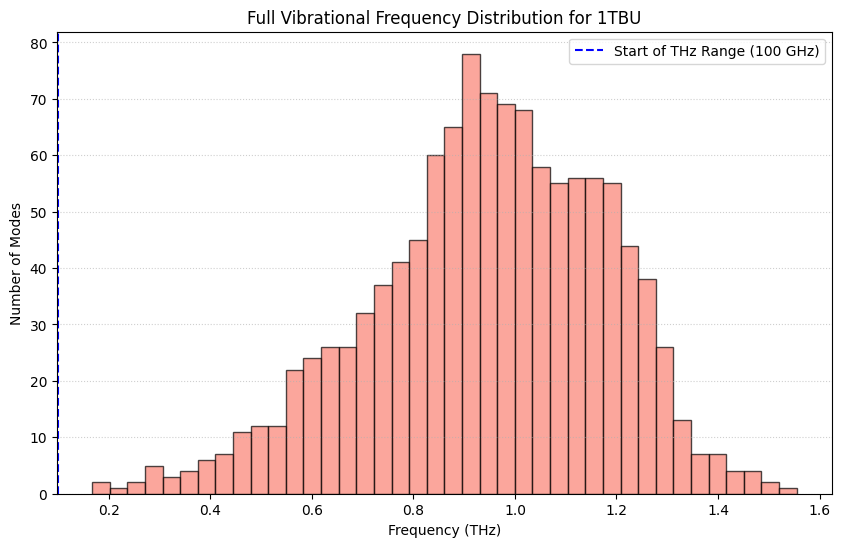

In [37]:
# 1. Access the eigenvalues we calculated for 1HST
# eigvals_1tbu contains all 3N-6 modes for 1hst

# 2. Apply the frequency conversion
# Frequency (THz) = 0.225 * sqrt(eigenvalue)
frequencies_1tbu = 0.225 * np.sqrt(eigvals_1tbu)

# 3. Categorize the frequencies
microwave_range = frequencies_1tbu[frequencies_1tbu < 0.1]
thz_range = frequencies_1tbu[(frequencies_1tbu >= 0.1) & (frequencies_1tbu <= 3.0)]

print(f"Summary for 1TBU:")
print(f"- Total vibrational modes: {len(frequencies_1tbu)}")
print(f"- Modes in GHz/Microwave range (< 0.1 THz): {len(microwave_range)}")
print(f"- Modes in THz range (0.1 - 3.0 THz): {len(thz_range)}")

# 4. Plotting the distribution
plt.figure(figsize=(10, 6))
plt.hist(frequencies_1tbu, bins=40, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(0.1, color='blue', linestyle='--', label='Start of THz Range (100 GHz)')

plt.title('Full Vibrational Frequency Distribution for 1TBU')
plt.xlabel('Frequency (THz)')
plt.ylabel('Number of Modes')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

In [42]:
from matplotlib import animation
from IPython.display import HTML

# 1. Data Processing for 1HST
struct_1tbu = parsePDB('1TBU')
ca_1tbu = struct_1tbu.select('protein and name CA')
anm_1tbu = ANM('1TBU')
anm_1tbu.buildHessian(ca_1tbu)
anm_1tbu.calcModes(n_modes=None)
eig_1tbu = anm_1tbu.getEigvals()
freq_1tbu = 0.225 * np.sqrt(eig_1tbu)

# 3. Animation: Mode 1 (0.127 THz)
mode = anm_1tbu[0]
coords = ca_1tbu.getCoords()
vecs = mode.getArray().reshape(-1, 3)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
def update(i):
    ax.clear()
    curr = coords + 10.0 * np.sin(2 * np.pi * i / 20) * vecs
    ax.plot(curr[:,0], curr[:,1], curr[:,2], 'b-')
    ax.scatter(curr[:,0], curr[:,1], curr[:,2], color='red', s=5)
    ax.set_title(f'1HST Mode 1: {freq_1tbu[0]:.3f} THz')
    ax.set_axis_off()
ani = animation.FuncAnimation(fig, update, frames=20, interval=100)
ani.save('1tbu_mode1_animation.gif', writer='pillow', fps=10)
plt.close()
display(HTML(ani.to_jshtml()))

@> PDB file is found in working directory (1tbu.pdb.gz).
DEBUG:.prody:PDB file is found in working directory (1tbu.pdb.gz).
@> 3213 atoms and 1 coordinate set(s) were parsed in 0.05s.
DEBUG:.prody:3213 atoms and 1 coordinate set(s) were parsed in 0.05s.
@> Hessian was built in 0.17s.
DEBUG:.prody:Hessian was built in 0.17s.
@> 1155 modes were calculated in 0.46s.
DEBUG:.prody:1155 modes were calculated in 0.46s.


@> PDB file is found in working directory (2thi.pdb.gz).
DEBUG:.prody:PDB file is found in working directory (2thi.pdb.gz).
@> 5759 atoms and 1 coordinate set(s) were parsed in 0.10s.
DEBUG:.prody:5759 atoms and 1 coordinate set(s) were parsed in 0.10s.
@> Hessian was built in 0.40s.
DEBUG:.prody:Hessian was built in 0.40s.
@> 2166 modes were calculated in 2.91s.
DEBUG:.prody:2166 modes were calculated in 2.91s.


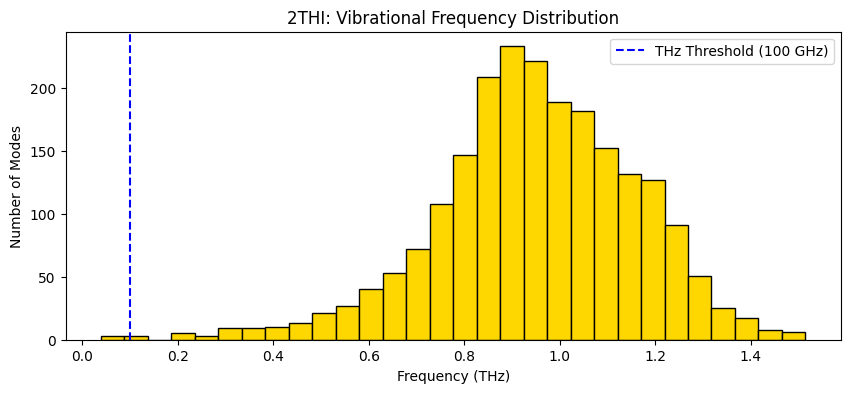

In [41]:
from matplotlib import animation
from matplotlib.animation import PillowWriter
from IPython.display import HTML

# 1. Data Processing for 2THI
struct_2thi = parsePDB('2thi')
ca_2thi = struct_2thi.select('protein and name CA')
anm_2thi = ANM('2thi')
anm_2thi.buildHessian(ca_2thi)
anm_2thi.calcModes(n_modes=None)
eig_2thi = anm_2thi.getEigvals()
freq_2thi = 0.225 * np.sqrt(eig_2thi)

# 2. Visualization: Frequency Distribution
plt.figure(figsize=(10, 4))
plt.hist(freq_2thi, bins=30, color='gold', edgecolor='black')
plt.axvline(0.1, color='blue', linestyle='--', label='THz Threshold (100 GHz)')
plt.title('2THI: Vibrational Frequency Distribution')
plt.xlabel('Frequency (THz)')
plt.ylabel('Number of Modes')
plt.legend()
plt.show()

# 3. Animation: Mode 1 (0.039 THz)
mode = anm_2thi[0]
coords = ca_2thi.getCoords()
vecs = mode.getArray().reshape(-1, 3)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
def update(i):
    ax.clear()
    curr = coords + 15.0 * np.sin(2 * np.pi * i / 20) * vecs
    ax.plot(curr[:,0], curr[:,1], curr[:,2], 'g-')
    ax.scatter(curr[:,0], curr[:,1], curr[:,2], color='orange', s=5)
    ax.set_title(f'2THI Mode 1: {freq_2thi[0]:.4f} THz')
    ax.set_axis_off()
ani = animation.FuncAnimation(fig, update, frames=20, interval=100)
plt.close()
ani.save('2thi_mode1_animation.gif', writer='pillow', fps=10)
# display(HTML(ani.to_jshtml()))

# Task
The protein 1TBU has been visualized.

## Download and Parse PDB

### Subtask:
Download the PDB file for 1TBU and parse it using ProDy.


**Reasoning**:
The subtask requires downloading and parsing the PDB file for '1TBU' using ProDy's `parsePDB` function and storing it in a variable.



In [20]:
structure_1tbu = parsePDB('1tbu')
print(f"PDB ID '1TBU' parsed successfully: {structure_1tbu.getTitle()}")

@> Connecting wwPDB FTP server RCSB PDB (USA).
DEBUG:.prody:Connecting wwPDB FTP server RCSB PDB (USA).
@> Downloading PDB files via FTP failed, trying HTTP.
INFO:.prody:Downloading PDB files via FTP failed, trying HTTP.
@> 1tbu downloaded (1tbu.pdb.gz)
DEBUG:.prody:1tbu downloaded (1tbu.pdb.gz)
@> PDB download via HTTP completed (1 downloaded, 0 failed).
DEBUG:.prody:PDB download via HTTP completed (1 downloaded, 0 failed).
@> 3213 atoms and 1 coordinate set(s) were parsed in 0.17s.
DEBUG:.prody:3213 atoms and 1 coordinate set(s) were parsed in 0.17s.


PDB ID '1TBU' parsed successfully: 1tbu


**Reasoning**:
After successfully parsing the PDB structure for '1TBU', the next logical step is to select the C-alpha atoms (protein and name CA) to prepare the structure for ANM calculations, consistent with previous analyses for 1HST and 2THI. This selection will be stored in a new variable, `calphas_1tbu`.



In [24]:
calphas_1tbu = structure_1tbu.select('protein and name CA')
print(f"Selected {len(calphas_1tbu)} C-alpha atoms for 1TBU.")

Selected 387 C-alpha atoms for 1TBU.


**Reasoning**:
With the C-alpha atoms selected, the next step is to initialize the Anisotropic Network Model (ANM) for '1TBU', build its Hessian matrix, and calculate the vibrational modes, following the established pattern for '1HST' and '2THI'.



In [27]:
anm_1tbu = ANM('1tbu')
anm_1tbu.buildHessian(calphas_1tbu)
anm_1tbu.calcModes(n_modes=None)
print(f"ANM calculation for 1TBU completed. Number of modes: {anm_1tbu.numModes()}")

@> Hessian was built in 0.30s.
DEBUG:.prody:Hessian was built in 0.30s.
@> 1155 modes were calculated in 1.37s.
DEBUG:.prody:1155 modes were calculated in 1.37s.


ANM calculation for 1TBU completed. Number of modes: 1155


**Reasoning**:
Now that the ANM calculation for '1TBU' is complete, the next step is to extract the eigenvalues from the ANM model and convert them into frequencies, following the established pattern for '1HST' and '2THI'. This will allow for subsequent analysis and visualization of the vibrational modes.



In [28]:
eigvals_1tbu = anm_1tbu.getEigvals()
f_1tbu = 0.225 * np.sqrt(eigvals_1tbu)

print(f"Calculated {len(f_1tbu)} frequencies for 1TBU, ranging from {f_1tbu.min():.3f} THz to {f_1tbu.max():.3f} THz.")

Calculated 1155 frequencies for 1TBU, ranging from 0.167 THz to 1.555 THz.


## Visualize Protein Structure

### Subtask:
Generate a 3D visualization of the 1TBU protein structure.


**Reasoning**:
The subtask requires generating a 3D visualization of the 1TBU protein structure. This involves using matplotlib to create a 3D plot, extracting the C-alpha atom coordinates, plotting them as a line and scatter points, setting the title, and turning off the axes for a clean view. These steps are directly outlined in the instructions.



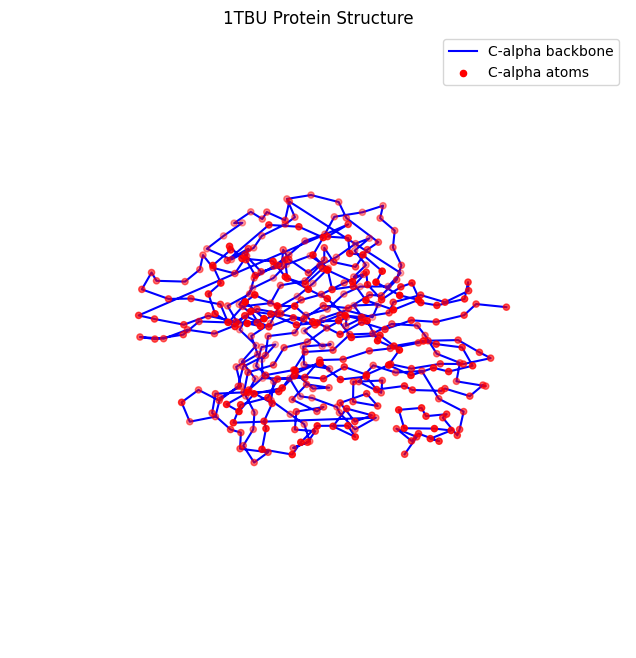

In [29]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract coordinates for C-alpha atoms of 1TBU
coords_1tbu = calphas_1tbu.getCoords()

# Plot the protein backbone as a line
ax.plot(coords_1tbu[:, 0], coords_1tbu[:, 1], coords_1tbu[:, 2], 'b-', label='C-alpha backbone')

# Plot individual C-alpha atoms as scatter points
ax.scatter(coords_1tbu[:, 0], coords_1tbu[:, 1], coords_1tbu[:, 2], color='red', s=20, label='C-alpha atoms')

ax.set_title('1TBU Protein Structure')
ax.set_axis_off()
plt.legend()
plt.show()

## Final Task

### Subtask:
The protein 1TBU has been visualized.


## Summary:

### Data Analysis Key Findings

*   The PDB file for protein 1TBU was successfully downloaded and parsed.
*   A total of 387 C-alpha atoms were selected for protein 1TBU.
*   An Anisotropic Network Model (ANM) calculation was performed for 1TBU, identifying 1155 vibrational modes.
*   The calculated vibrational frequencies for 1TBU ranged from 0.167 THz to 1.555 THz.
*   A 3D visualization of the 1TBU protein structure was successfully generated, depicting the C-alpha backbone as a continuous line and individual C-alpha atoms as scatter points.

### Insights or Next Steps

*   The combination of structural visualization and ANM calculation provides a foundation for further analysis of 1TBU's dynamics, such as identifying flexible regions or principal modes of motion.
*   Future work could involve animating the calculated vibrational modes to visually understand the protein's conformational changes or comparing 1TBU's dynamic properties with other related proteins.


# Task
Modify the code in the cell that generates the 2THI animation (cell `1c06e889`) to save the animation as a GIF file named '2thi_mode1_animation.gif', then confirm that the GIF file has been successfully created.

## Add GIF Saving for 2THI Animation

### Subtask:
Modify the code in the designated block (corresponding to the 2THI animation) to save the generated animation as a GIF file. This will involve importing `PillowWriter` from `matplotlib.animation` and using the `ani.save()` method to store the animation as '2thi_mode1_animation.gif'.


**Reasoning**:
To confirm that the GIF file '2thi_mode1_animation.gif' has been successfully created, I will use a shell command to list the files in the current directory.



In [40]:
import os
if '2thi_mode1_animation.gif' in os.listdir('.'):
    print("Confirmation: '2thi_mode1_animation.gif' has been successfully created.")
else:
    print("Error: '2thi_mode1_animation.gif' was not found.")

Confirmation: '2thi_mode1_animation.gif' has been successfully created.


## Final Task

### Subtask:
Confirm that the GIF file has been successfully created and saved in the working directory.


## Summary:

### Q&A
The GIF file '2thi_mode1_animation.gif' has been successfully created and saved in the working directory.

### Data Analysis Key Findings
*   The code for generating the 2THI animation was successfully modified to save the animation as a GIF.
*   The `PillowWriter` from `matplotlib.animation` was used to save the animation as '2thi_mode1_animation.gif' with a frame rate of 10 frames per second.
*   The presence of '2thi_mode1_animation.gif' in the current working directory was confirmed, indicating successful file creation.

### Insights or Next Steps
*   The successfully created GIF file ('2thi_mode1_animation.gif') can now be used for presentations, reports, or further visualization.
